# Pagoda2.1 Single-Dataset Workflow

This notebook shows the current pagoda2.1 single-dataset workflow on a
PBMC sample from GEO:
[GSM5746259](https://www.ncbi.nlm.nih.gov/geo/query/acc.cgi?acc=GSM5746259).

The count data are downloaded from that GEO sample page as a 10x-style
triplet: a sparse matrix file, a cell barcode file, and a gene/feature
file. Here those three files are in a local folder named `data`.

## Input Data

The folder contains the three files needed for a 10x-style sparse count
matrix. The next cell shows the folder name and the files that were
downloaded from GEO.

``` r
data_dir <- "data"

data.frame(
  data_dir = data_dir,
  file = list.files(data_dir, pattern = "\\.(mtx|tsv)(\\.gz)?$")
)
```

  data_dir                                            file
1     data GSM5746259_MGI0369_1_SLAB-145-0.barcodes.tsv.gz
2     data GSM5746259_MGI0369_1_SLAB-145-0.features.tsv.gz
3     data   GSM5746259_MGI0369_1_SLAB-145-0.matrix.mtx.gz

Create the pagoda2 object directly from that folder. The reader keeps
raw counts in the object and creates a lightweight normalized analysis
view for downstream calculations.

``` r
p2 <- suppressMessages(pagoda2::Pagoda2$from10x(data_dir, verbose = FALSE))
counts <- p2$getRawCounts()

data.frame(
  cells = nrow(counts),
  genes = ncol(counts),
  nonzero_entries = Matrix::nnzero(counts),
  sparsity = round(1 - Matrix::nnzero(counts) / prod(dim(counts)), 4),
  integer_like = all(abs(counts@x - round(counts@x)) < 1e-8)
)
```

  cells genes nonzero_entries sparsity integer_like
1  7532 36601        12364316   0.9551         TRUE

## QC

`runQC()` records molecule counts, detected-gene counts, and a
gene-versus-molecule QC decision in `p2$cellMeta`. Mitochondrial and
ribosomal percentages are included when the gene annotation supports
common prefix matching.

``` r
suppressMessages(invisible(p2$runQC(verbose = FALSE)))
qc <- p2$resolveCellMeta(c("n_molecules", "n_genes", "qc_pass"))

data.frame(
  cells = nrow(qc),
  qc_pass = sum(as.logical(qc$qc_pass), na.rm = TRUE),
  qc_fail = sum(!as.logical(qc$qc_pass), na.rm = TRUE),
  fail_fraction = round(mean(!as.logical(qc$qc_pass), na.rm = TRUE), 4),
  median_molecules = median(qc$n_molecules, na.rm = TRUE),
  median_genes = median(qc$n_genes, na.rm = TRUE)
)
```

  cells qc_pass qc_fail fail_fraction median_molecules median_genes
1  7532    7415     117        0.0155           3800.5         1536

The main QC plot shows detected genes versus molecule counts. Cells
failing the default QC decision are highlighted in red.

``` r
p2$plotQC()
```

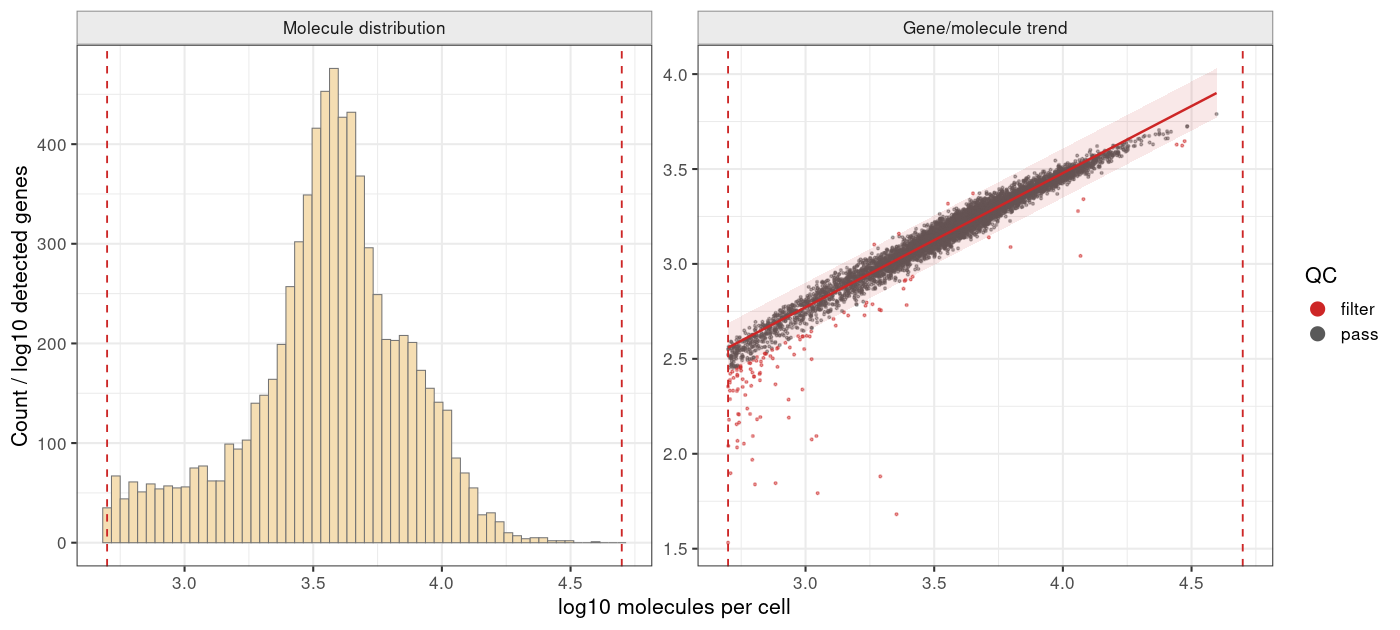

Composition QC is annotation-dependent. Here the sample has recognizable
mitochondrial and ribosomal gene prefixes, so the violin plot is
informative.

``` r
p2$plotQCViolin()
```

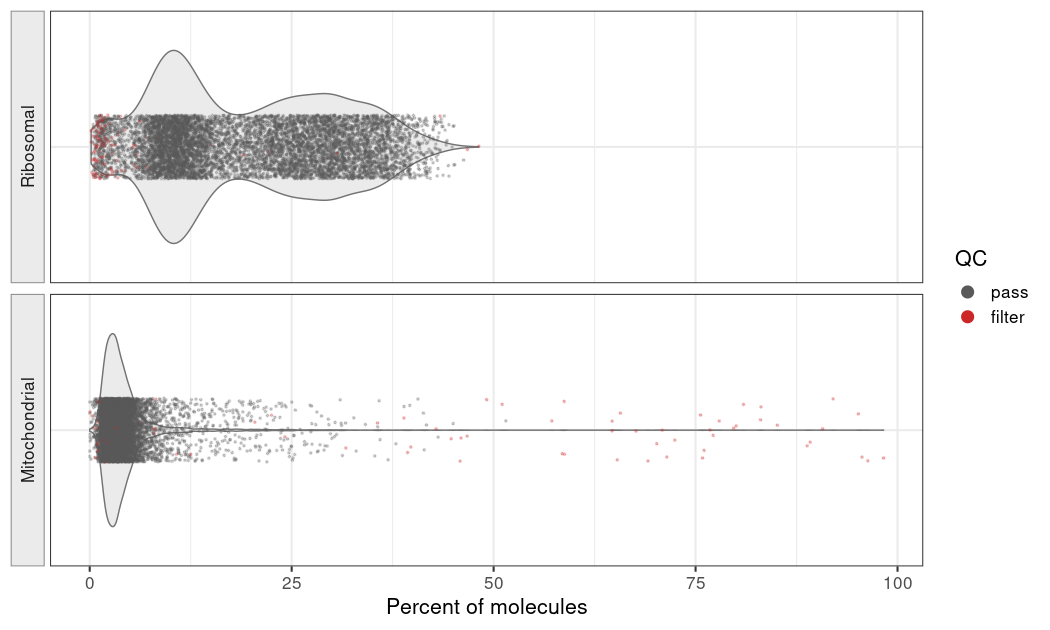

## Run The Default Workflow

The standard run performs filtering, variance modeling, PCA, graph
construction, UMAP, Leiden clustering, and marker detection. Results are
stored under canonical names so plotting calls can usually omit
selectors.

``` r
suppressMessages(invisible(p2$run(plots = "none", verbose = FALSE)))

groups <- p2$getGrouping()
summary <- data.frame(
  cells = nrow(p2$getRawCounts()),
  raw_genes = ncol(p2$getRawCounts()),
  analysis_genes = sum(p2$resolveGeneMeta("analysis_pass")$analysis_pass),
  od_genes = length(p2$misc$odgenes),
  default_grouping = p2$getDefaultGrouping(),
  clusters = length(levels(groups))
)
summary
```

  cells raw_genes analysis_genes od_genes default_grouping clusters
1  7415     36601          17064      903           leiden       13

``` r
cluster_sizes <- sort(table(p2$getGrouping()), decreasing = TRUE)
head(data.frame(cluster = names(cluster_sizes), cells = as.integer(cluster_sizes)), 15)
```

   cluster cells
1        1  1370
2        2  1355
3        3   898
4        4   668
5        5   658
6        6   566
7        7   504
8        8   462
9        9   422
10      10   200
11      11   134
12      12   114
13      13    64

## PCA And UMAP

The PCA elbow plot shows percent total variance explained by each PC and
cumulatively. Use it to assess whether the default PC range is
reasonable before interpreting the graph and embedding.

``` r
p2$plotPCAElbow()
```

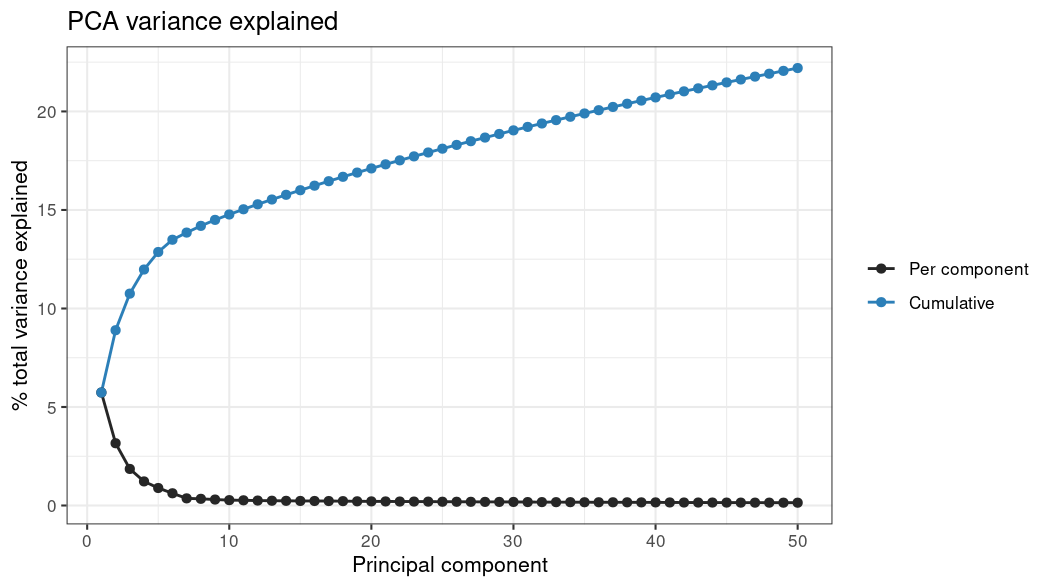

The UMAP below is colored by the default Leiden clustering. Check for
coherent clusters, tiny outlying groups, and possible QC or batch
structure before annotating cell types.

``` r
p2$plotEmbedding(
  mark.groups = TRUE,
  size = 0.35,
  alpha = 0.55,
  title = "GSM5746259 Leiden clusters"
)
```

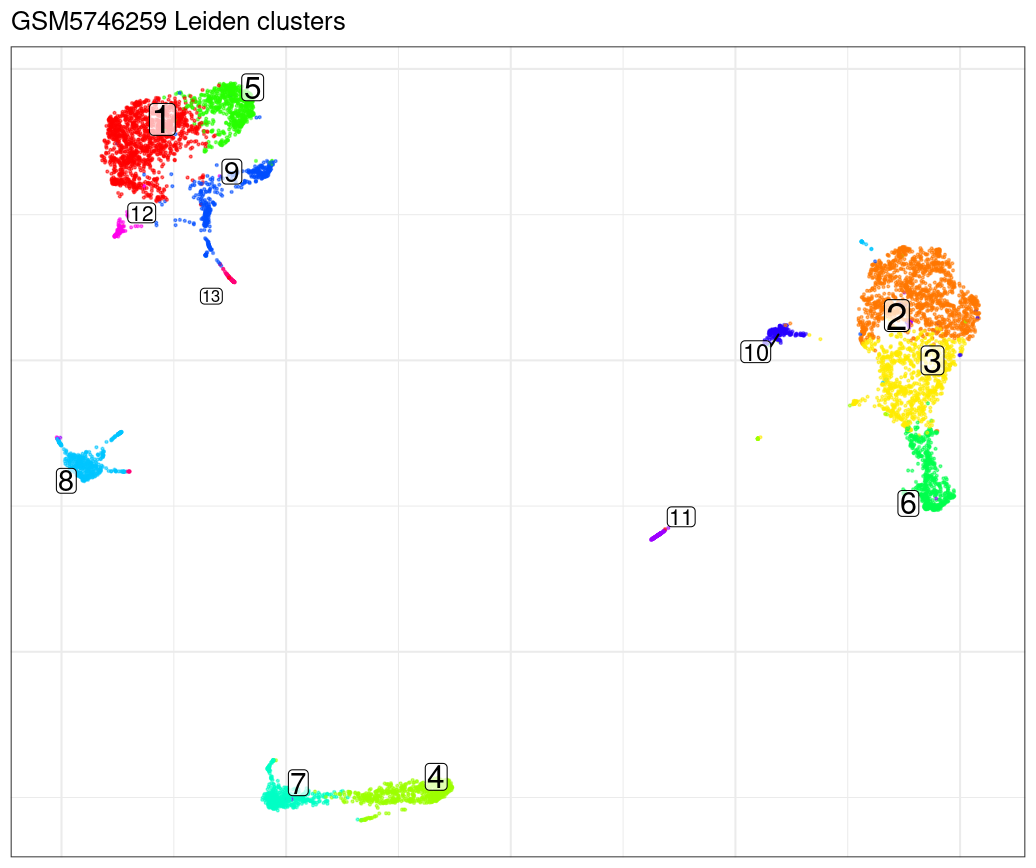

## Marker Genes

The default run stores marker genes for the default grouping. The dot
plot and heatmap use the same marker result and marker-selection logic.

``` r
marker_name <- "leiden"
marker_name
```

[1] "leiden"

``` r
p2$plotMarkerDotPlot(
  markers = marker_name,
  n.genes.per.group = 5,
  selection = "balanced",
  order.groups = TRUE,
  dot.scale = 8.5
) + ggplot2::labs(title = "Leiden marker genes")
```

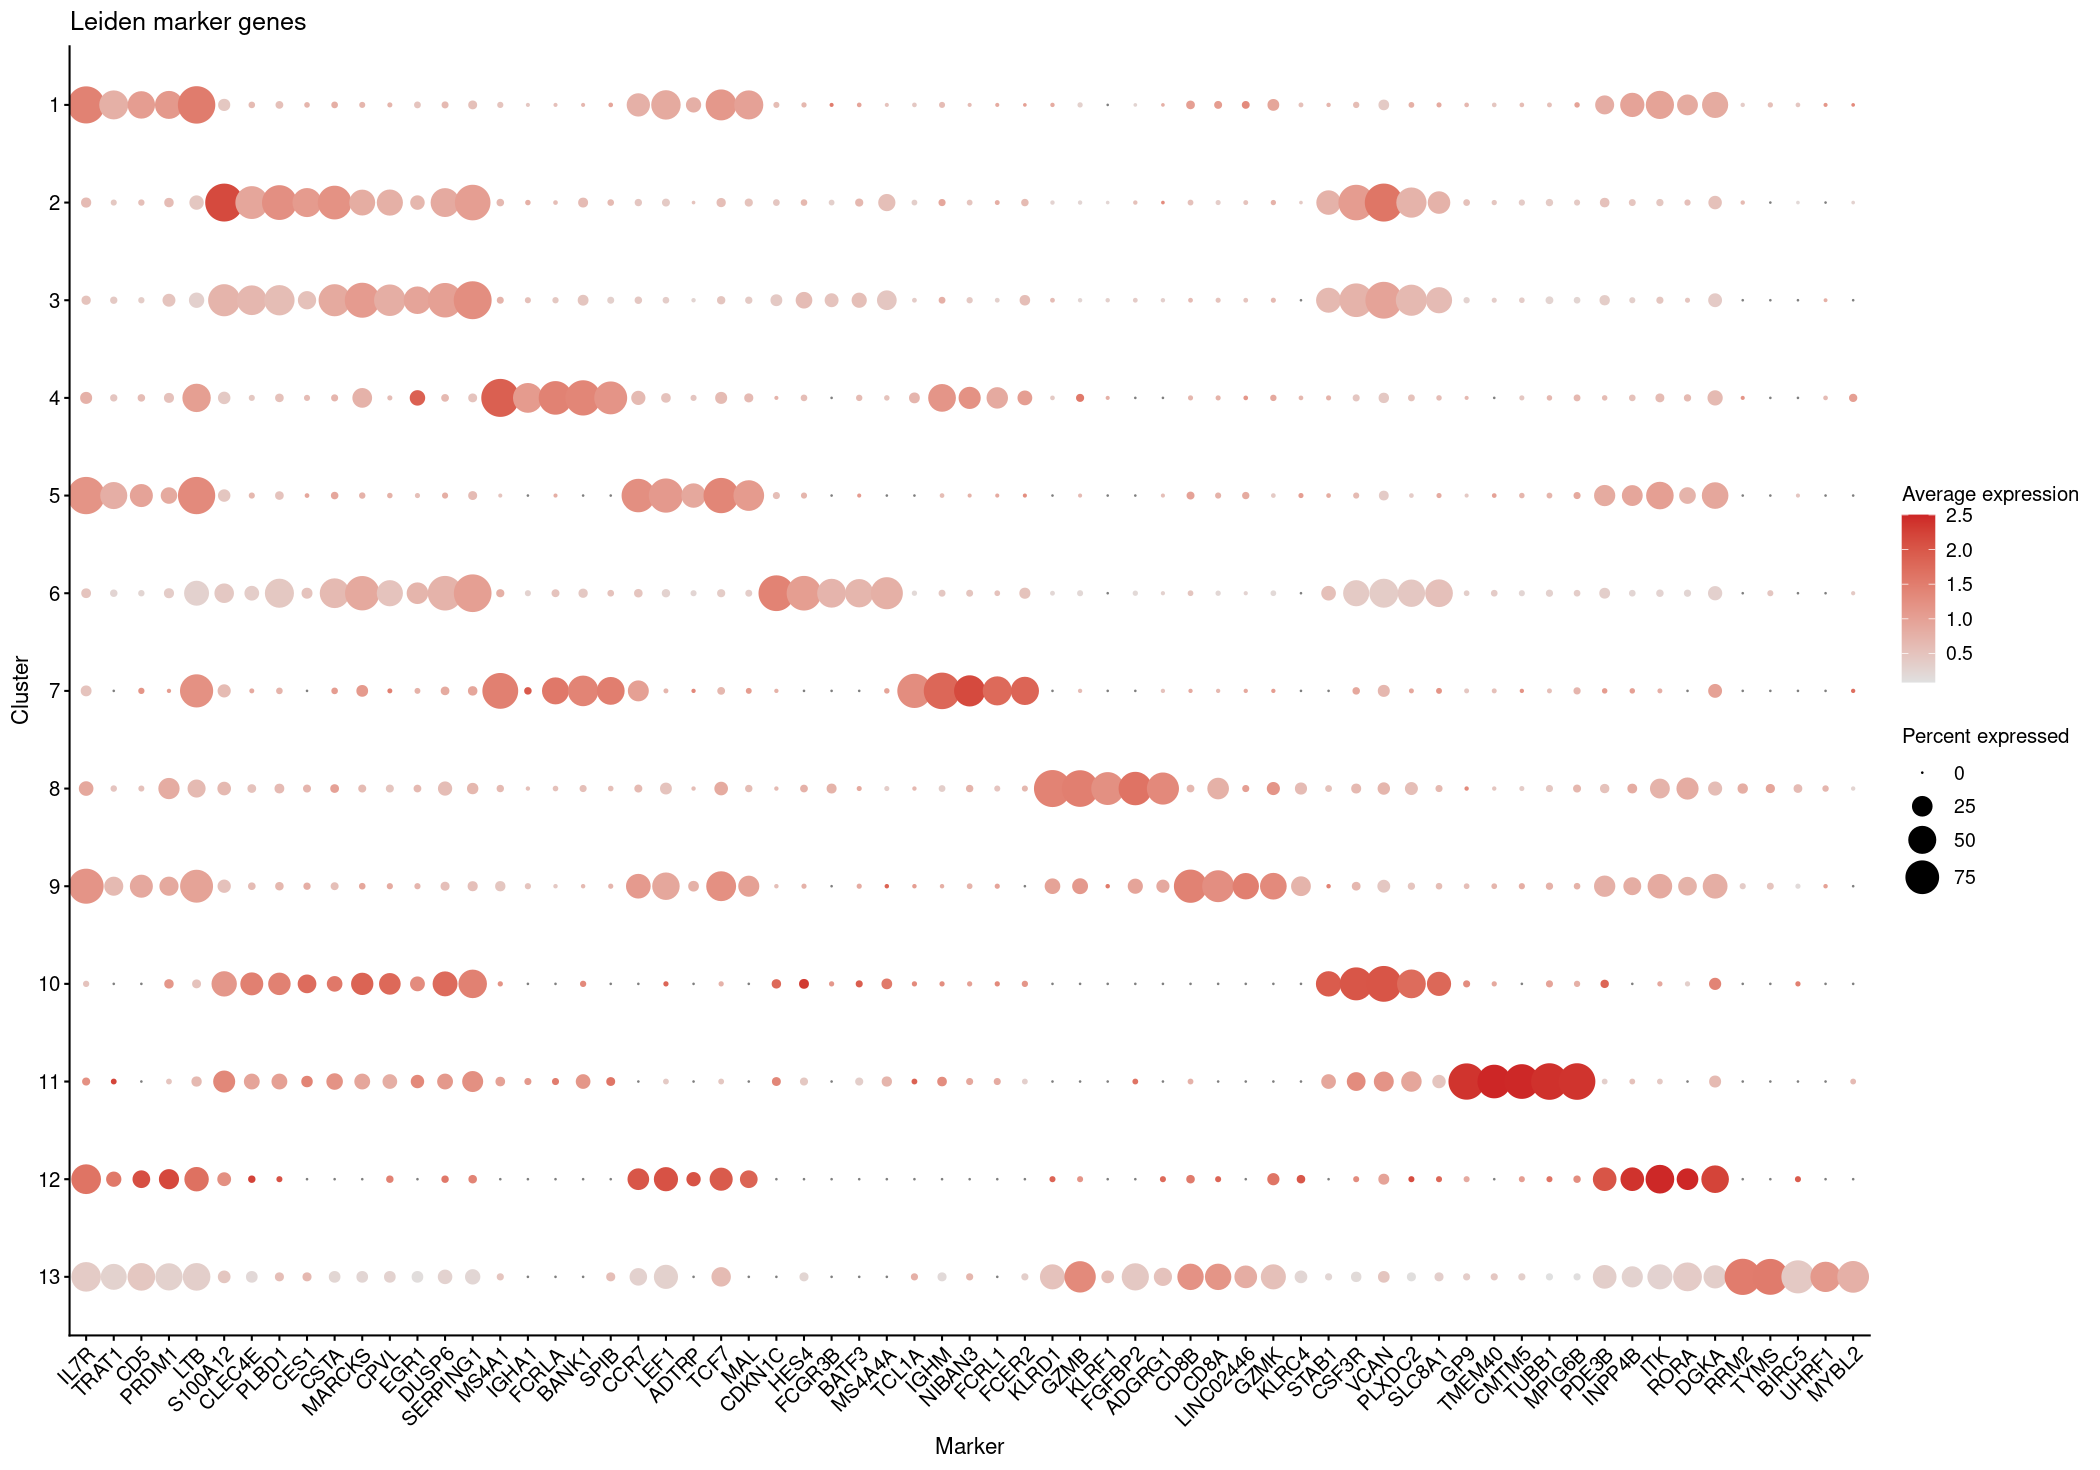

The native marker heatmap avoids a heavy ComplexHeatmap dependency. The
top tracks show QC metrics so marker blocks can be inspected together
with per-cell quality summaries.

``` r
p2$plotMarkerHeatmap(
  markers = marker_name,
  engine = "native",
  n.genes.per.group = 3,
  selection = "balanced",
  column.metadata = c("n_molecules", "n_genes"),
  row.label.font.size = 9,
  split = TRUE,
  show_heatmap_legend = TRUE
)
```

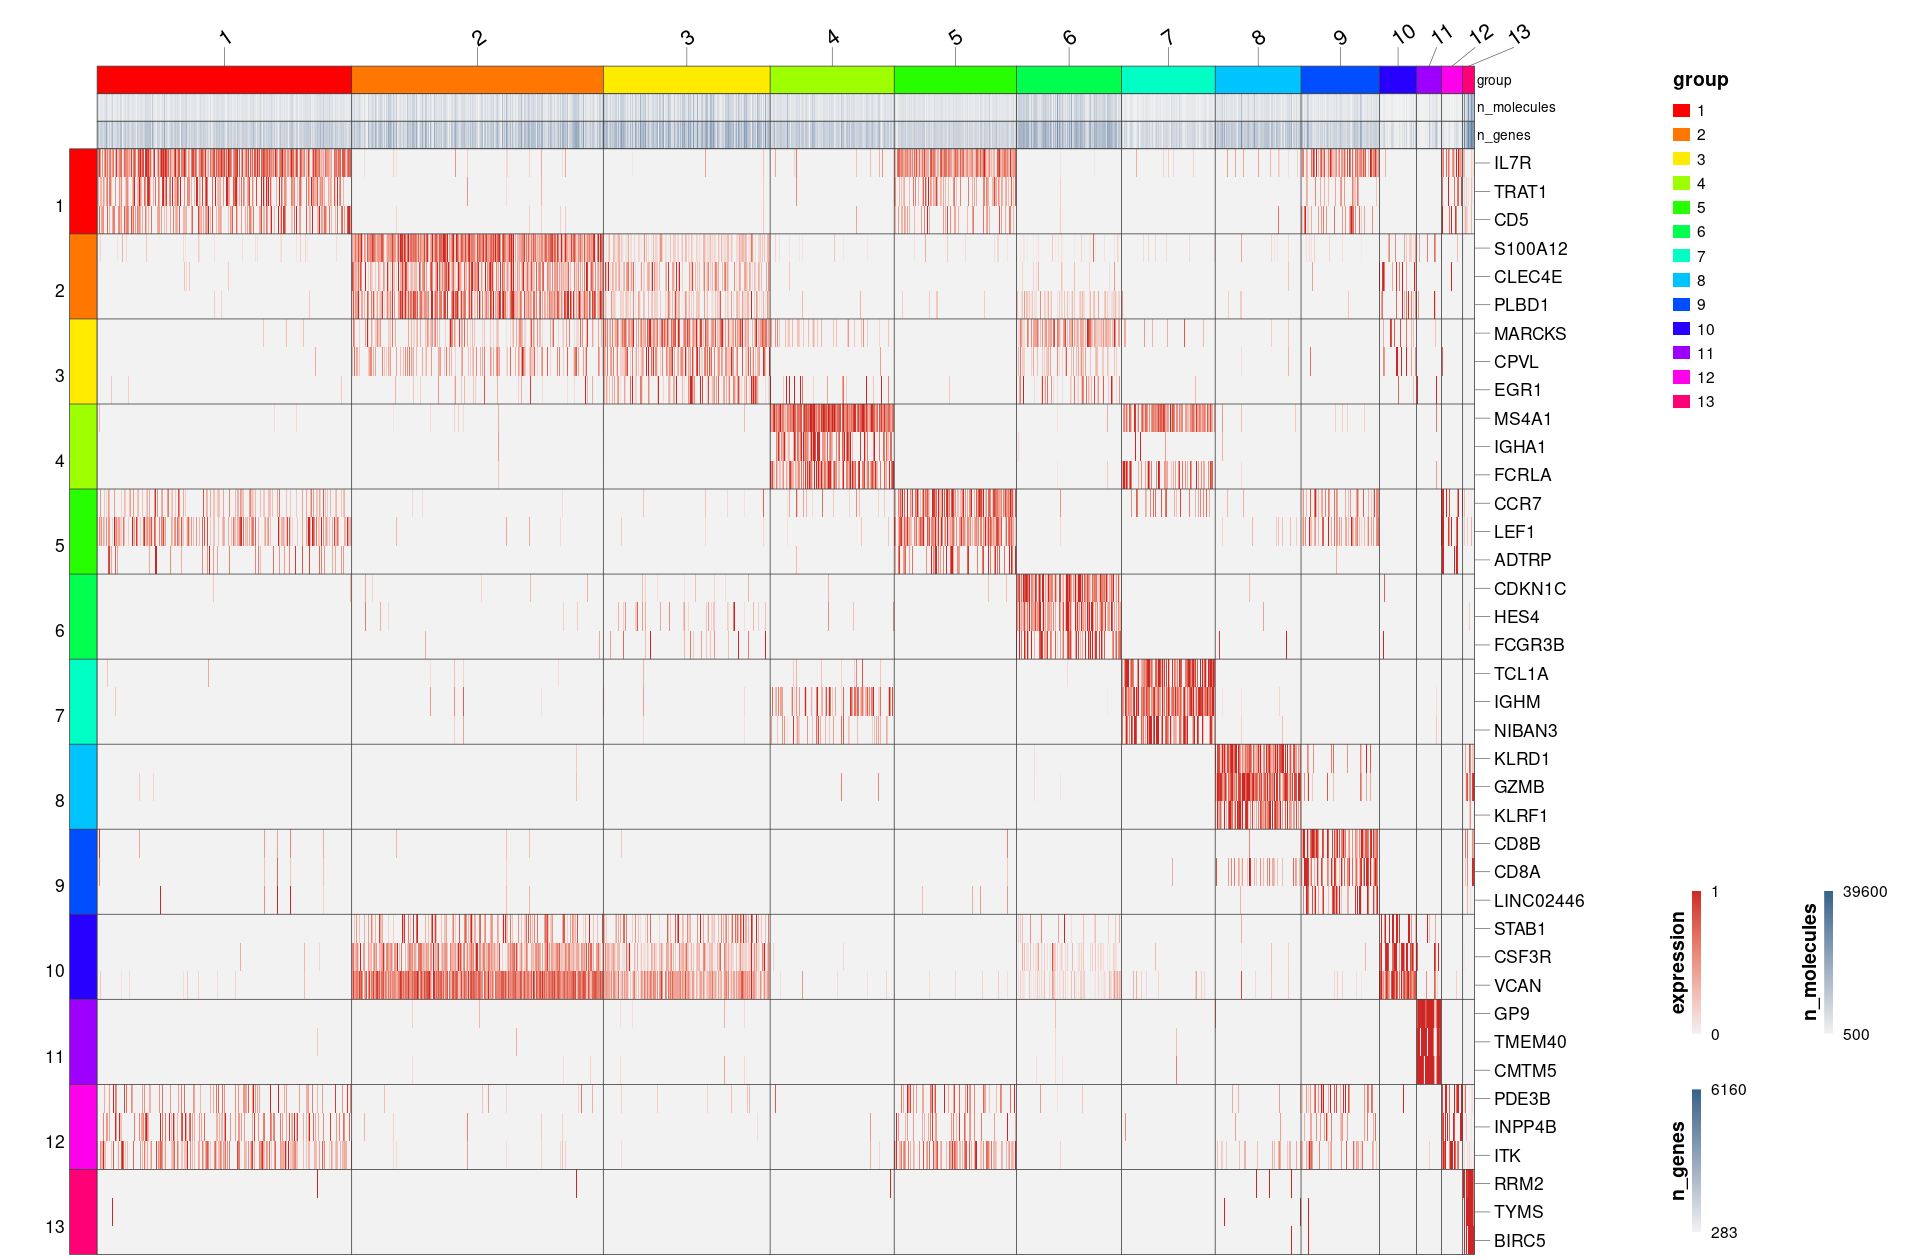

## Next Steps

For real analyses, the next step is usually biological annotation. Store
cluster annotations as another cell metadata column and make it the
default grouping when appropriate:

``` r
p2$annotateClusters(
  from = "leiden",
  to = "cell_type",
  map = c("1" = "T cells", "2" = "monocytes"),
  setDefault = TRUE
)
```

After that, the same plotting and marker methods will use `cell_type` by
default unless a different grouping is requested.